In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE
from itertools import product as iproduct
from sklearn.metrics import f1_score, accuracy_score

In [3]:
FILES = ["S07main_EpochedNoseRefCleanTimesFixed.mat"]
FSAMPLE     = 512
TOTAL_TIMES = 1229
T_STIMULUS  = 822   # index of stimulus onset (t=0 s)
T_POST      = 407   # post-stimulus samples
BANDS = {"delta":(1,4), "theta":(4,8), "alpha":(8,13), "beta":(13,30)}

In [4]:
#method to load data
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0,0] if item.size==1 and item.ndim>1 else (item[0] if item.size==1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0,0]

def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0,0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v); trials.extend(t)
    trials = np.array(trials); vals = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]   # labels {0,1}, trials

In [5]:
y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)   # (trials, timesteps, channels)
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")

#split data
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

#normalise data
mean = X_tr_raw.mean(axis=(0,1), keepdims=True)
std  = X_tr_raw.std(axis=(0,1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train/Test: {len(y_train)}/{len(y_test)}")


Trials: 222  |  Class 0: 134  Class 1: 88
Train/Test: 177/45


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

#defining transformer architecture
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, layers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        return torch.sigmoid(self.fc(x.mean(dim=1)))

#training transformer modek
def train_transformer(X, y_lbl, epochs=30, batch_size=32, lr=1e-3):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = TransformerModel(X.shape[2]).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def predict_transformer(model, X):
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    return (p > 0.5).astype(int)

Device: cpu


In [7]:
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

In [10]:
#grid search

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0)

#nhead must divide d_model evenly!!!
param_grid = {
    'd_model':    [8, 16, 32],
    'nhead':      [2, 4],
    'layers':     [1, 2],
    'dropout':    [0.0],
    'lr':         [1e-3],
    'batch_size': [16, 32],
}

def train_transformer_hp(X, y_lbl, d_model, nhead, layers, dropout, lr, batch_size, epochs=30):
    """Like train_transformer but exposes all hyperparameters."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = TransformerModel(X.shape[2], d_model=d_model, nhead=nhead,
                                layers=layers, dropout=dropout).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(-1), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

#used to troubleshoot when d_model and nhead don't work together
keys   = list(param_grid.keys())
combos = [c for c in iproduct(*param_grid.values())
          if dict(zip(keys, c))['d_model'] % dict(zip(keys, c))['nhead'] == 0]
print(f"Grid search over {len(combos)} valid combinations...")
print(f"{'#':>4}  {'Acc':>6}  {'F1':>6}  {'Bias':>6}  Params")
print("-" * 75)

best_f1, best_params, results = -1, None, []

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    model  = train_transformer_hp(X_tr2, y_tr2, **params)
    preds  = predict_transformer(model, X_val)
    f1     = f1_score(y_val, preds, average='macro', zero_division=0)
    acc    = accuracy_score(y_val, preds)
    bias   = preds.mean()  # proportion predicted class 1 (0.5 = balanced)
    results.append({'params': params, 'f1': f1, 'acc': acc, 'bias': bias})
    print(f"[{i+1:>3}/{len(combos)}]  {acc:.4f}  {f1:.4f}  {bias:.4f}  {params}")
    if f1 > best_f1:
        best_f1, best_params = f1, params

#summary of best combinations
print(f"\n{'='*75}")
print("Top 5 combinations by macro-F1:")
print(f"{'Acc':>6}  {'F1':>6}  {'Bias':>6}  Params")
print("-" * 65)
for r in sorted(results, key=lambda x: x['f1'], reverse=True)[:5]:
    print(f"{r['acc']:.4f}  {r['f1']:.4f}  {r['bias']:.4f}  {r['params']}")
print(f"{'='*75}")


Grid search over 24 valid combinations...
   #     Acc      F1    Bias  Params
---------------------------------------------------------------------------
[  1/24]  0.6389  0.4995  0.1389  {'d_model': 8, 'nhead': 2, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  2/24]  0.6111  0.3793  0.0556  {'d_model': 8, 'nhead': 2, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  3/24]  0.5278  0.5092  0.4722  {'d_model': 8, 'nhead': 2, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  4/24]  0.6667  0.5556  0.1667  {'d_model': 8, 'nhead': 2, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  5/24]  0.6389  0.4526  0.0833  {'d_model': 8, 'nhead': 4, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  6/24]  0.6667  0.4680  0.0556  {'d_model': 8, 'nhead': 4, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  7/24]  0.6944  0.6303  0.2500  {'d_model': 8, 'nhead': 4, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16

ValueError: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])) is deprecated. Please ensure they have the same size.


Re-training best config on full training set...

  Transformer — Best hyperparameters (grid search)
              precision    recall  f1-score   support

     Class 0     0.6667    1.0000    0.8000        28
     Class 1     1.0000    0.1765    0.3000        17

    accuracy                         0.6889        45
   macro avg     0.8333    0.5882    0.5500        45
weighted avg     0.7926    0.6889    0.6111        45



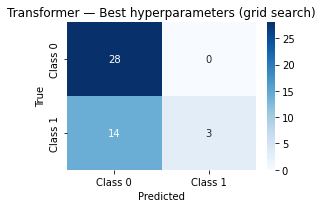

In [12]:
def train_transformer_hp(X, y_lbl, d_model, nhead, layers, dropout, lr, batch_size, epochs=30):
    """Like train_transformer but exposes all hyperparameters."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = TransformerModel(X.shape[2], d_model=d_model, nhead=nhead,
                                layers=layers, dropout=dropout).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(-1), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model


print("\nRe-training best config on full training set...")
best_model = train_transformer_hp(X_train, y_train, **best_params)
show_results("Transformer — Best hyperparameters (grid search)", y_test, predict_transformer(best_model, X_test))
